# Card Transaction Fraud Detection
## Notebook 4 — Sampling Strategies, ML Models, Iteration Experiments and Tuning

**Input:** `features_v2.pkl` (features from Notebook 2 + cluster and anomaly score from Notebook 3)

**What this notebook does**
- **A. Data preparation:** select features, encode categories, transform skewed values, create a validation period
- **B. Sampling strategies:** train the same models on differently sampled training data and compare
- **C. All models:** Logistic Regression, Decision Tree, Random Forest, XGBoost, LightGBM (+ simple benchmarks)
- **D. Iteration experiments:** how performance changes with 100 / 200 / 500 / 1000 trees (and LR iterations)
- **E. Tuning:** small hyperparameter search for LightGBM
- **F. Final models:** retrain on the full training file and evaluate **once** on the untouched test file

**How data is used (important for the report)**

| Period | Used for |
|---|---|
| Train file, all but last 90 days | fitting models during experiments |
| Train file, last 90 days (**validation**) | choosing sampling strategy, iterations, settings, thresholds |
| Test file (Jun–Dec 2020) | **final evaluation only** — never used for any choice |

> Run the cells **in order**. Some cells take several minutes (marked ⏱). Press Ctrl+S after each section.

In [1]:
%pip install xgboost lightgbm imbalanced-learn

  Using cached lightgbm-4.7.0-py3-none-win_amd64.whl.metadata (18 kB)
  Using cached imbalanced_learn-0.14.2-py3-none-any.whl.metadata (8.9 kB)
  Using cached sklearn_compat-0.1.6-py3-none-any.whl.metadata (22 kB)
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 17.5 MB/s eta 0:00:06
   - -------------------------------------- 2.6/101.7 MB 10.8 MB/s eta 0:00:10
   - -------------------------------------- 3.7/101.7 MB 8.1 MB/s eta 0:00:13
   -- ------------------------------------- 6.0/101.7 MB 8.8 MB/s eta 0:00:11
   ---- ----------------------------------- 11.3/101.7 MB 12.6 MB/s eta 0:00:08
   ------ --------------------------------- 16.5/101.7 MB 15.1 MB/s eta 0:00:06
   -------- ------------------------------- 22.8/101.7 MB 17.6 MB/s eta 0:00:05
   ----------- ---------------------------- 28.8/101.7 MB 18.9 MB/s eta 0:00:04
   -------


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 0. Setup

In [1]:
import os, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import (average_precision_score, roc_auc_score, precision_recall_curve,
                             precision_score, recall_score, f1_score, confusion_matrix)
from sklearn.exceptions import ConvergenceWarning
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
import lightgbm as lgb
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)
sns.set_style('whitegrid')
RANDOM_STATE = 42

BASE = os.path.join(os.path.expanduser('~'), 'fraud-outputs')
FIG_DIR = os.path.join(BASE, 'figures')
TBL_DIR = os.path.join(BASE, 'tables')
MODEL_DIR = os.path.join(BASE, 'models')
for d in [FIG_DIR, TBL_DIR, MODEL_DIR]:
    os.makedirs(d, exist_ok=True)

def save_fig(name):
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, name), dpi=300, bbox_inches='tight')
    plt.show()

def save_tbl(df_, name, index=True):
    df_.to_csv(os.path.join(TBL_DIR, name), index=index)

print('Outputs will be saved to:', BASE)

Outputs will be saved to: C:\Users\adith\fraud-outputs


## A. Data preparation

**Feature choices**
- Amount, spend-vs-usual and time-since-previous are **log-transformed** (very skewed; helps Logistic Regression, harmless for trees).
- Hour is kept as a number **and** as sin/cos (so 23:00 and 00:00 are "close") plus the night flag.
- Merchant category and gender are **one-hot encoded**.
- **Excluded:** names, street, city, zip, card number, transaction ID, exact coordinates, job, date of birth —
  they identify people rather than describe behaviour, or would let a model memorise individuals.
- Cluster and anomaly score from Notebook 3 are **not** used here; Notebook 5 tests whether adding them helps.

In [2]:
df = pd.read_pickle(os.path.join(BASE, 'features_v2.pkl'))
df = df.sort_values('trans_date_trans_time').reset_index(drop=True)

# Transformations
df['log_amt_vs_avg'] = np.log1p(df['amt_vs_card_avg'])
df['log_hours_since_prev'] = np.log1p(df['hours_since_prev'])
df['log_city_pop'] = np.log1p(df['city_pop'])
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['gender_M'] = (df['gender'] == 'M').astype(int)

cat_dummies = pd.get_dummies(df['category'], prefix='cat', dtype=int)
df = pd.concat([df, cat_dummies], axis=1)

FEATURES = (['log_amt', 'log_amt_vs_avg', 'log_hours_since_prev', 'txn_count_1h', 'txn_count_24h',
             'is_first_txn', 'hour', 'hour_sin', 'hour_cos', 'is_night', 'is_weekend', 'day_of_week',
             'age', 'distance_km', 'log_city_pop', 'gender_M']
            + list(cat_dummies.columns))
print(f'{len(FEATURES)} model features:')
print(FEATURES)

30 model features:
['log_amt', 'log_amt_vs_avg', 'log_hours_since_prev', 'txn_count_1h', 'txn_count_24h', 'is_first_txn', 'hour', 'hour_sin', 'hour_cos', 'is_night', 'is_weekend', 'day_of_week', 'age', 'distance_km', 'log_city_pop', 'gender_M', 'cat_entertainment', 'cat_food_dining', 'cat_gas_transport', 'cat_grocery_net', 'cat_grocery_pos', 'cat_health_fitness', 'cat_home', 'cat_kids_pets', 'cat_misc_net', 'cat_misc_pos', 'cat_personal_care', 'cat_shopping_net', 'cat_shopping_pos', 'cat_travel']


In [3]:
# Time-based split of the TRAIN file into fit (earlier) and validation (last 90 days)
train_all = df[df['split'] == 'train']
test_df = df[df['split'] == 'test']
val_start = train_all['trans_date_trans_time'].max() - pd.Timedelta(days=90)

fit_df = train_all[train_all['trans_date_trans_time'] < val_start]
val_df = train_all[train_all['trans_date_trans_time'] >= val_start]

def xy(d):
    return d[FEATURES].to_numpy(dtype=np.float32), d['is_fraud'].to_numpy()

X_fit, y_fit = xy(fit_df)
X_val, y_val = xy(val_df)
X_train_all, y_train_all = xy(train_all)
X_test, y_test = xy(test_df)
clusters_fit = fit_df['cluster'].to_numpy()
clusters_train_all = train_all['cluster'].to_numpy()

split_summary = pd.DataFrame({
    'period': [f"{d['trans_date_trans_time'].min():%Y-%m-%d} to {d['trans_date_trans_time'].max():%Y-%m-%d}"
               for d in [fit_df, val_df, train_all, test_df]],
    'rows': [len(fit_df), len(val_df), len(train_all), len(test_df)],
    'frauds': [int(fit_df['is_fraud'].sum()), int(val_df['is_fraud'].sum()),
               int(train_all['is_fraud'].sum()), int(test_df['is_fraud'].sum())],
}, index=['Fit (experiments)', 'Validation (choices)', 'Full train (final models)', 'Test (final evaluation)'])
split_summary['fraud_rate_pct'] = (split_summary['frauds'] / split_summary['rows'] * 100).round(3)
save_tbl(split_summary, '04_00_data_splits.csv')
split_summary

,period,rows,frauds,fraud_rate_pct
Fit (experiments),2019-01-01 to 2020-03-23,1076870,6272,0.582
Validation (choices),2020-03-23 to 2020-06-21,219805,1234,0.561
Full train (final models),2019-01-01 to 2020-06-21,1296675,7506,0.579
Test (final evaluation),2020-06-21 to 2020-12-31,555719,2145,0.386


### Helper functions
- `evaluate()` computes **PR-AUC** (main metric — threshold-free and suited to rare fraud), ROC-AUC, and precision / recall / F1
  at the threshold that gives the best F1.
- `make_model()` builds each model with consistent settings. `balanced=True` turns on class weights.

In [11]:
def best_f1_threshold(y, p):
    prec, rec, thr = precision_recall_curve(y, p)
    f1 = np.where(prec[:-1] + rec[:-1] > 0, 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-12), 0)
    i = int(np.argmax(f1))
    return float(thr[i])

def evaluate(y, p, threshold=None):
    if threshold is None:
        threshold = best_f1_threshold(y, p)
    pred = (p >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    return {'PR_AUC': average_precision_score(y, p), 'ROC_AUC': roc_auc_score(y, p),
            'threshold': threshold,
            'precision': precision_score(y, pred, zero_division=0),
            'recall': recall_score(y, pred, zero_division=0),
            'F1': f1_score(y, pred, zero_division=0),
            'frauds_caught': int(tp), 'frauds_missed': int(fn), 'false_alarms': int(fp)}

def make_model(name, balanced=False, n_estimators=200, y_for_weight=None, **kw):
    if name == 'Logistic Regression':
        return make_pipeline(StandardScaler(), LogisticRegression(
            max_iter=kw.get('max_iter', 1000), class_weight='balanced' if balanced else None))
    if name == 'Decision Tree':
        return DecisionTreeClassifier(max_depth=12, min_samples_leaf=20, random_state=RANDOM_STATE,
                                      class_weight='balanced' if balanced else None)
    if name == 'Random Forest':
        return RandomForestClassifier(n_estimators=n_estimators, max_depth=16, min_samples_leaf=5,
                                      max_samples=None, n_jobs=-1, random_state=RANDOM_STATE,
                                      class_weight='balanced' if balanced else None,
                                      warm_start=kw.get('warm_start', False))
    if name == 'XGBoost':
        spw = (len(y_for_weight) - y_for_weight.sum()) / y_for_weight.sum() if balanced else 1.0
        return XGBClassifier(n_estimators=n_estimators, learning_rate=kw.get('learning_rate', 0.1),
                             max_depth=6, subsample=0.8, colsample_bytree=0.8, tree_method='hist',
                             scale_pos_weight=spw, eval_metric='aucpr', n_jobs=-1,
                             random_state=RANDOM_STATE)
    if name == 'LightGBM':
        params = dict(n_estimators=n_estimators, learning_rate=kw.get('learning_rate', 0.1),
                      num_leaves=kw.get('num_leaves', 31), min_child_samples=kw.get('min_child_samples', 20),
                      subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
                      class_weight='balanced' if balanced else None,
                      n_jobs=-1, random_state=RANDOM_STATE, verbose=-1)
        return LGBMClassifier(**params)
    raise ValueError(name)

def fit_predict(name, X, y, Xv, balanced=False, **kw):
    model = make_model(name, balanced=balanced, y_for_weight=y, **kw)
    t0 = time.perf_counter()
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', ConvergenceWarning)
        model.fit(X, y)
    secs = time.perf_counter() - t0
    return model, model.predict_proba(Xv)[:, 1], secs

print('Helpers ready.')

Helpers ready.


## B. Sampling strategies

All strategies change **only the training (fit) data**. Validation and test always keep the real fraud rate,
so the comparison reflects real-world performance.

| Strategy | What it does |
|---|---|
| No balancing | all data, as it is |
| Class weights | all data, but mistakes on fraud cost more during training |
| Random sample 20% | a random 20% of the data (tests whether less data hurts) |
| Stratified sample 20% | 20% sample that keeps the exact fraud rate |
| Random undersampling 1:10 | keep all fraud, randomly keep 10 legitimate per fraud |
| SMOTE 1:10 | create synthetic fraud examples until fraud = 10% of legitimate |
| Cluster-based undersampling 1:10 | keep all fraud, take legitimate **equally from each Notebook 3 cluster** |

Each strategy is tested with **Logistic Regression** (simple) and **LightGBM** (powerful). ⏱ About 5–15 minutes.

In [6]:
def resample(strategy, X, y, clusters):
    """Returns X, y and whether class weights should be switched on."""
    rng = np.random.default_rng(RANDOM_STATE)
    if strategy == 'No balancing':
        return X, y, False
    if strategy == 'Class weights':
        return X, y, True
    if strategy == 'Random sample 20%':
        idx = rng.choice(len(y), size=int(len(y) * 0.2), replace=False)
        return X[idx], y[idx], False
    if strategy == 'Stratified sample 20%':
        idx, _ = train_test_split(np.arange(len(y)), train_size=0.2, stratify=y, random_state=RANDOM_STATE)
        return X[idx], y[idx], False
    if strategy == 'Random undersampling 1:10':
        Xr, yr = RandomUnderSampler(sampling_strategy=0.1, random_state=RANDOM_STATE).fit_resample(X, y)
        return Xr, yr, False
    if strategy == 'SMOTE 1:10':
        Xr, yr = SMOTE(sampling_strategy=0.1, random_state=RANDOM_STATE).fit_resample(X, y)
        return Xr, yr, False
    if strategy == 'Cluster-based undersampling 1:10':
        fraud_idx = np.where(y == 1)[0]
        n_legit_target = len(fraud_idx) * 10
        ks = np.unique(clusters)
        per_cluster = n_legit_target // len(ks)
        legit_idx = []
        for k in ks:
            pool = np.where((y == 0) & (clusters == k))[0]
            legit_idx.append(rng.choice(pool, size=min(per_cluster, len(pool)), replace=False))
        idx = np.concatenate([fraud_idx] + legit_idx)
        return X[idx], y[idx], False
    raise ValueError(strategy)

STRATEGIES = ['No balancing', 'Class weights', 'Random sample 20%', 'Stratified sample 20%',
              'Random undersampling 1:10', 'SMOTE 1:10', 'Cluster-based undersampling 1:10']

rows = []
for strat in STRATEGIES:
    Xs, ys, balanced = resample(strat, X_fit, y_fit, clusters_fit)
    for name in ['Logistic Regression', 'LightGBM']:
        _, p, secs = fit_predict(name, Xs, ys, X_val, balanced=balanced)
        m = evaluate(y_val, p)
        rows.append({'strategy': strat, 'model': name, 'train_rows': len(ys),
                     'train_fraud_pct': round(ys.mean() * 100, 2), 'train_seconds': round(secs, 1), **m})
        print(f"{strat:<34} {name:<20} PR-AUC={m['PR_AUC']:.3f}  recall={m['recall']:.3f}  "
              f"precision={m['precision']:.3f}  ({secs:.0f}s)")

sampling_results = pd.DataFrame(rows)
save_tbl(sampling_results.round(4), '04_01_sampling_strategies.csv', index=False)

No balancing                       Logistic Regression  PR-AUC=0.486  recall=0.431  precision=0.636  (4s)
No balancing                       LightGBM             PR-AUC=0.533  recall=0.777  precision=0.601  (10s)
Class weights                      Logistic Regression  PR-AUC=0.343  recall=0.374  precision=0.558  (5s)
Class weights                      LightGBM             PR-AUC=0.949  recall=0.861  precision=0.924  (13s)
Random sample 20%                  Logistic Regression  PR-AUC=0.488  recall=0.436  precision=0.640  (1s)
Random sample 20%                  LightGBM             PR-AUC=0.408  recall=0.660  precision=0.511  (3s)
Stratified sample 20%              Logistic Regression  PR-AUC=0.486  recall=0.408  precision=0.682  (1s)
Stratified sample 20%              LightGBM             PR-AUC=0.313  recall=0.666  precision=0.384  (3s)
Random undersampling 1:10          Logistic Regression  PR-AUC=0.407  recall=0.428  precision=0.527  (0s)
Random undersampling 1:10          LightGBM 

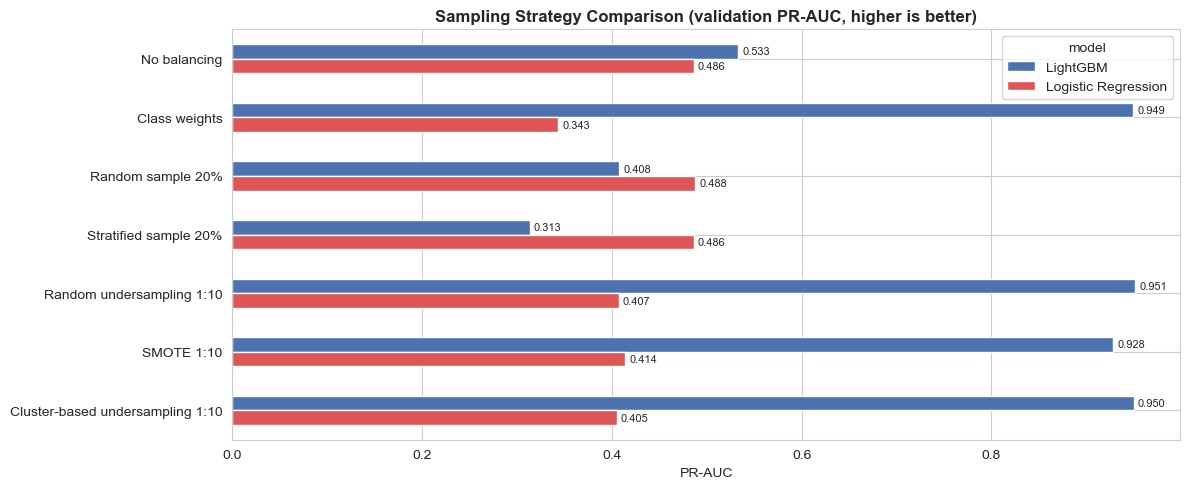

Best strategy (by LightGBM validation PR-AUC): Random undersampling 1:10


PR_AUC                       recall                     precision                    
model                            LightGBM Logistic Regression LightGBM Logistic Regression  LightGBM Logistic Regression
strategy                                                                                                                
No balancing                        0.533               0.486    0.777               0.431     0.601               0.636
Class weights                       0.949               0.343    0.861               0.374     0.924               0.558
Random sample 20%                   0.408               0.488    0.660               0.436     0.511               0.640
Stratified sample 20%               0.313               0.486    0.666               0.408     0.384               0.682
Random undersampling 1:10           0.951               0.407    0.875               0.428     0.903               0.527
SMOTE 1:10                          0.928               0.414    0.867               0.393     0.934               0.607
Cluster-based undersampling 1:10    0.950               0.405    0.867               0.432     0.928               0.517

In [7]:
pivot = sampling_results.pivot(index='strategy', columns='model', values='PR_AUC').loc[STRATEGIES]

fig, ax = plt.subplots(figsize=(12, 5))
pivot.plot(kind='barh', ax=ax, color=['#4C72B0', '#DD5555'])
ax.set_title('Sampling Strategy Comparison (validation PR-AUC, higher is better)', fontweight='bold')
ax.set_xlabel('PR-AUC')
ax.set_ylabel('')
ax.invert_yaxis()
for c in ax.containers:
    ax.bar_label(c, fmt='%.3f', padding=3, fontsize=8)
save_fig('04_01_sampling_comparison.png')

lgb_rank = sampling_results[sampling_results['model'] == 'LightGBM'].sort_values('PR_AUC', ascending=False)
BEST_STRATEGY = lgb_rank.iloc[0]['strategy']
print('Best strategy (by LightGBM validation PR-AUC):', BEST_STRATEGY)
# To override, uncomment and edit:  BEST_STRATEGY = 'Class weights'
sampling_results.pivot(index='strategy', columns='model', values=['PR_AUC', 'recall', 'precision']).loc[STRATEGIES].round(3)

## C. All models with the chosen sampling strategy

Five models with standard settings (200 trees for the ensembles), plus two simple **benchmarks** the models must beat:
- **Amount rule:** flag every transaction above $200 (from the EDA)
- **Isolation Forest:** the unsupervised anomaly score from Notebook 3

⏱ About 5–15 minutes (Random Forest is the slowest).

In [15]:
Xs, ys, balanced = resample(BEST_STRATEGY, X_fit, y_fit, clusters_fit)
print(f'Training rows after "{BEST_STRATEGY}": {len(ys):,} (fraud {ys.mean()*100:.2f}%)')

MODELS = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost', 'LightGBM']
val_probs, rows = {}, []
for name in MODELS:
    _, p, secs = fit_predict(name, Xs, ys, X_val, balanced=balanced)
    val_probs[name] = p
    m = evaluate(y_val, p)
    rows.append({'model': name, 'train_seconds': round(secs, 1), **m})
    print(f"{name:<20} PR-AUC={m['PR_AUC']:.3f}  ROC-AUC={m['ROC_AUC']:.3f}  F1={m['F1']:.3f}  ({secs:.0f}s)")

# Benchmarks
val_probs['Amount rule (>$200)'] = (val_df['amt'].to_numpy() > 200).astype(float)
val_probs['Isolation Forest (unsupervised)'] = val_df['anomaly_score'].to_numpy()
rows.append({'model': 'Amount rule (>$200)', 'train_seconds': 0,
             **evaluate(y_val, val_probs['Amount rule (>$200)'], threshold=0.5)})
rows.append({'model': 'Isolation Forest (unsupervised)', 'train_seconds': np.nan,
             **evaluate(y_val, val_probs['Isolation Forest (unsupervised)'])})

model_results_val = pd.DataFrame(rows).sort_values('PR_AUC', ascending=False)
save_tbl(model_results_val.round(4), '04_02_models_validation.csv', index=False)
model_results_val.round(3)

Training rows after "Random undersampling 1:10": 68,992 (fraud 9.09%)
Logistic Regression  PR-AUC=0.407  ROC-AUC=0.939  F1=0.472  (0s)
Decision Tree        PR-AUC=0.762  ROC-AUC=0.992  F1=0.781  (1s)
Random Forest        PR-AUC=0.882  ROC-AUC=0.996  F1=0.835  (7s)
XGBoost              PR-AUC=0.947  ROC-AUC=0.999  F1=0.889  (2s)
LightGBM             PR-AUC=0.951  ROC-AUC=0.999  F1=0.889  (1s)


,model,train_seconds,PR_AUC,ROC_AUC,threshold,precision,recall,F1,frauds_caught,frauds_missed,false_alarms
4,LightGBM,1.1,0.951,0.999,0.910,0.903,0.875,0.889,1080,154,116
3,XGBoost,1.6,0.947,0.999,0.908,0.920,0.859,0.889,1060,174,92
2,Random Forest,6.8,0.882,0.996,0.768,0.894,0.784,0.835,967,267,115
1,Decision Tree,1.1,0.762,0.992,1.000,0.840,0.729,0.781,900,334,172
0,Logistic Regression,0.2,0.407,0.939,0.779,0.527,0.428,0.472,528,706,473
6,Isolation Forest (unsupervised),NaN,0.166,0.896,0.622,0.286,0.393,0.331,485,749,1209
5,Amount rule (>$200),0.0,0.072,0.863,0.500,0.091,0.769,0.163,949,285,9431


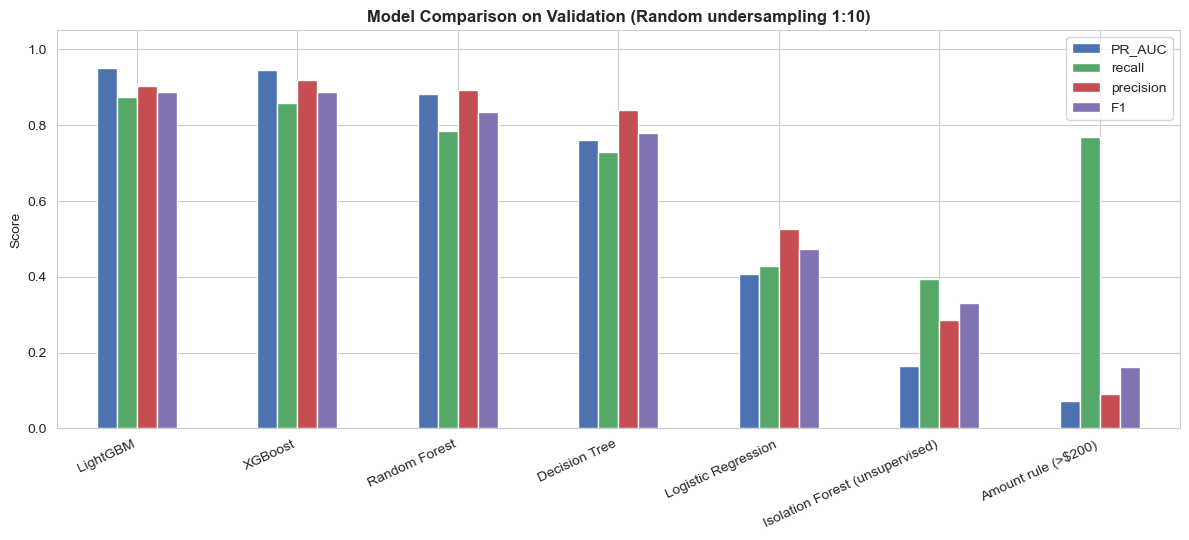

In [16]:
plot_df = model_results_val.set_index('model')[['PR_AUC', 'recall', 'precision', 'F1']]
fig, ax = plt.subplots(figsize=(12, 5.5))
plot_df.plot(kind='bar', ax=ax, color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'])
ax.set_title(f'Model Comparison on Validation ({BEST_STRATEGY})', fontweight='bold')
ax.set_ylabel('Score')
ax.set_xlabel('')
ax.set_ylim(0, 1.05)
plt.xticks(rotation=25, ha='right')
save_fig('04_02_model_comparison_validation.png')

## D. Iteration experiments — does more training help?

- **LightGBM and XGBoost:** trained once with up to 1000 trees (learning rate 0.05), and scored on validation every 50 trees.
- **Random Forest:** grown to 100, 200, 500 and 1000 trees (trees are added on top of the previous ones).
- **Logistic Regression:** maximum solver iterations 25, 50, 100, 200, 500, 1000.

This shows where extra training stops helping — or starts **overfitting** (validation score falling while training continues).
⏱ About 10–25 minutes.

In [17]:
CHECKPOINTS = list(range(50, 1001, 50))
iter_rows = []

# --- Boosting models: one fit with 1000 trees, scored at every checkpoint
for name in ['LightGBM', 'XGBoost']:
    model = make_model(name, balanced=balanced, n_estimators=1000, learning_rate=0.05, y_for_weight=ys)
    t0 = time.perf_counter()
    model.fit(Xs, ys)
    total = time.perf_counter() - t0
    for k in CHECKPOINTS:
        if name == 'LightGBM':
            p = model.predict_proba(X_val, num_iteration=k)[:, 1]
        else:
            p = model.predict_proba(X_val, iteration_range=(0, k))[:, 1]
        iter_rows.append({'model': name, 'iterations': k, 'PR_AUC': average_precision_score(y_val, p),
                          'ROC_AUC': roc_auc_score(y_val, p), 'train_seconds_approx': total * k / 1000})
    print(f'{name}: done ({total:.0f}s for 1000 trees)')

# --- Random Forest: grow the same forest step by step
rf = make_model('Random Forest', balanced=balanced, n_estimators=100, warm_start=True)
elapsed = 0
for k in [100, 200, 500,1000]:
    rf.set_params(n_estimators=k)
    t0 = time.perf_counter()
    rf.fit(Xs, ys)
    elapsed += time.perf_counter() - t0
    p = rf.predict_proba(X_val)[:, 1]
    iter_rows.append({'model': 'Random Forest', 'iterations': k, 'PR_AUC': average_precision_score(y_val, p),
                      'ROC_AUC': roc_auc_score(y_val, p), 'train_seconds_approx': elapsed})
    print(f'Random Forest {k} trees: PR-AUC={iter_rows[-1]["PR_AUC"]:.3f} ({elapsed:.0f}s so far)')

# --- Logistic Regression: solver iterations
for it in [25, 50, 100, 200, 500, 1000]:
    model, p, secs = fit_predict('Logistic Regression', Xs, ys, X_val, balanced=balanced, max_iter=it)
    n_used = int(model[-1].n_iter_[0])
    iter_rows.append({'model': 'Logistic Regression', 'iterations': it, 'PR_AUC': average_precision_score(y_val, p),
                      'ROC_AUC': roc_auc_score(y_val, p), 'train_seconds_approx': secs,
                      'converged': n_used < it})

iteration_results = pd.DataFrame(iter_rows)
save_tbl(iteration_results.round(4), '04_03_iteration_experiments.csv', index=False)
print('Iteration experiments complete.')

LightGBM: done (7s for 1000 trees)
XGBoost: done (8s for 1000 trees)
Random Forest 100 trees: PR-AUC=0.882 (4s so far)
Random Forest 200 trees: PR-AUC=0.882 (8s so far)
Random Forest 500 trees: PR-AUC=0.886 (19s so far)
Random Forest 1000 trees: PR-AUC=0.886 (38s so far)
Iteration experiments complete.


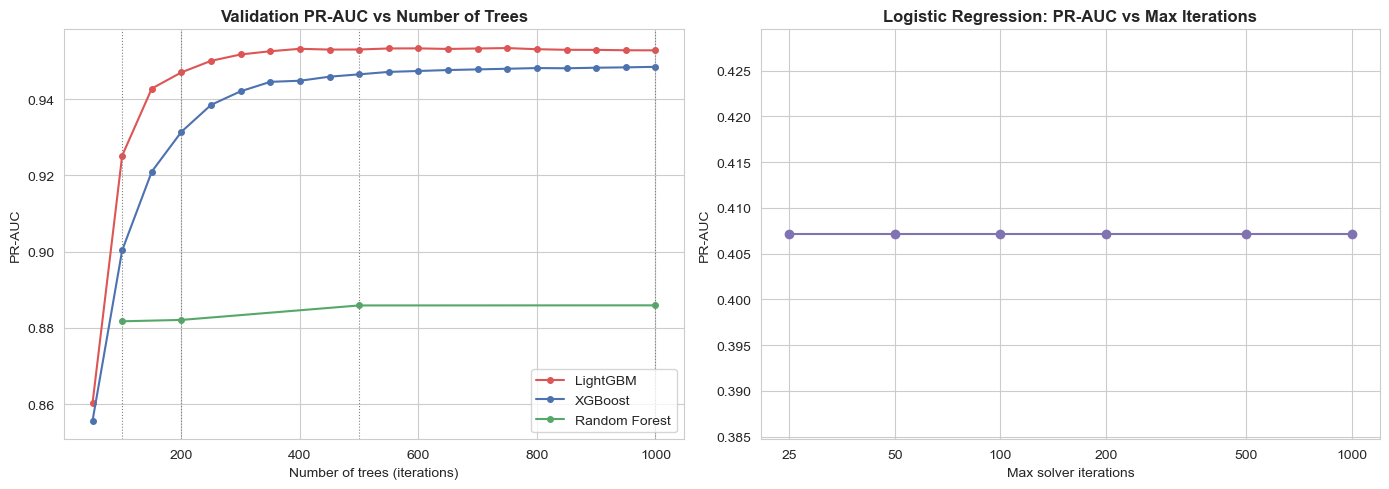

Best number of trees on validation: {'LightGBM': 750, 'XGBoost': 1000, 'Random Forest': 1000}


iterations,100,200,500,1000
model,,,,
LightGBM,0.9252,0.9470,0.9530,0.9528
Logistic Regression,0.4071,0.4071,0.4071,0.4071
Random Forest,0.8817,0.8821,0.8859,0.8859
XGBoost,0.9003,0.9314,0.9465,0.9485


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {'LightGBM': '#DD5555', 'XGBoost': '#4C72B0', 'Random Forest': '#55A868'}
for name, c in colors.items():
    d = iteration_results[iteration_results['model'] == name]
    axes[0].plot(d['iterations'], d['PR_AUC'], marker='o', ms=4, color=c, label=name)
for k in [100, 200, 500, 1000]:
    axes[0].axvline(k, color='grey', ls=':', lw=0.8)
axes[0].set_title('Validation PR-AUC vs Number of Trees', fontweight='bold')
axes[0].set_xlabel('Number of trees (iterations)')
axes[0].set_ylabel('PR-AUC')
axes[0].legend()

d = iteration_results[iteration_results['model'] == 'Logistic Regression']
axes[1].plot(d['iterations'], d['PR_AUC'], marker='o', color='#8172B2')
axes[1].set_xscale('log')
axes[1].set_xticks(d['iterations'])
axes[1].set_xticklabels(d['iterations'])
axes[1].set_title('Logistic Regression: PR-AUC vs Max Iterations', fontweight='bold')
axes[1].set_xlabel('Max solver iterations')
axes[1].set_ylabel('PR-AUC')
save_fig('04_03_iteration_curves.png')

key = iteration_results[iteration_results['iterations'].isin([100, 200, 500, 1000])]
key_table = key.pivot(index='model', columns='iterations', values='PR_AUC').round(4)
save_tbl(key_table, '04_04_iterations_key_points.csv')

BEST_N = {}
for name in ['LightGBM', 'XGBoost', 'Random Forest']:
    d = iteration_results[iteration_results['model'] == name]
    BEST_N[name] = int(d.loc[d['PR_AUC'].idxmax(), 'iterations'])
print('Best number of trees on validation:', BEST_N)
key_table

## E. Tuning LightGBM

A small search over the settings that matter most. Each combination uses **early stopping**: training stops
once validation PR-AUC hasn't improved for 50 rounds, so the number of trees is chosen automatically. ⏱ About 5–15 minutes.

In [19]:
GRID = [
    {'num_leaves': 31,  'learning_rate': 0.05, 'min_child_samples': 20},
    {'num_leaves': 31,  'learning_rate': 0.10, 'min_child_samples': 20},
    {'num_leaves': 63,  'learning_rate': 0.05, 'min_child_samples': 20},
    {'num_leaves': 63,  'learning_rate': 0.05, 'min_child_samples': 100},
    {'num_leaves': 127, 'learning_rate': 0.05, 'min_child_samples': 50},
    {'num_leaves': 127, 'learning_rate': 0.03, 'min_child_samples': 100},
    {'num_leaves': 15,  'learning_rate': 0.10, 'min_child_samples': 50},
    {'num_leaves': 255, 'learning_rate': 0.03, 'min_child_samples': 200},
   
]

tune_rows, best = [], None
for i, params in enumerate(GRID, 1):
    model = make_model('LightGBM', balanced=balanced, n_estimators=2000, **params)
    t0 = time.perf_counter()
    model.fit(Xs, ys, eval_set=[(X_val, y_val)], eval_metric='average_precision',
              callbacks=[lgb.early_stopping(50, verbose=False)])
    secs = time.perf_counter() - t0
    p = model.predict_proba(X_val, num_iteration=model.best_iteration_)[:, 1]
    score = average_precision_score(y_val, p)
    tune_rows.append({**params, 'best_iteration': model.best_iteration_, 'PR_AUC': score,
                      'ROC_AUC': roc_auc_score(y_val, p), 'train_seconds': round(secs, 1)})
    print(f'{i}/{len(GRID)} {params} -> PR-AUC={score:.4f} at {model.best_iteration_} trees ({secs:.0f}s)')
    if best is None or score > best['PR_AUC']:
        best = {**params, 'best_iteration': model.best_iteration_, 'PR_AUC': score}
        val_probs['LightGBM (tuned)'] = p

tuning_results = pd.DataFrame(tune_rows).sort_values('PR_AUC', ascending=False)
save_tbl(tuning_results.round(4), '04_05_lightgbm_tuning.csv', index=False)
BEST_LGB_PARAMS = {k: best[k] for k in ['num_leaves', 'learning_rate', 'min_child_samples']}
BEST_LGB_TREES = max(int(best['best_iteration']), 50)
default_lgb = model_results_val.loc[model_results_val['model'] == 'LightGBM', 'PR_AUC'].iloc[0]
print(f'\nBest settings: {BEST_LGB_PARAMS}, trees={BEST_LGB_TREES}')
print(f"Validation PR-AUC: default LightGBM {default_lgb:.4f} -> tuned {best['PR_AUC']:.4f}")
tuning_results.round(4)

1/8 {'num_leaves': 31, 'learning_rate': 0.05, 'min_child_samples': 20} -> PR-AUC=0.9533 at 401 trees (14s)
2/8 {'num_leaves': 31, 'learning_rate': 0.1, 'min_child_samples': 20} -> PR-AUC=0.9529 at 254 trees (9s)
3/8 {'num_leaves': 63, 'learning_rate': 0.05, 'min_child_samples': 20} -> PR-AUC=0.9531 at 373 trees (15s)
4/8 {'num_leaves': 63, 'learning_rate': 0.05, 'min_child_samples': 100} -> PR-AUC=0.9500 at 245 trees (11s)
5/8 {'num_leaves': 127, 'learning_rate': 0.05, 'min_child_samples': 50} -> PR-AUC=0.9510 at 251 trees (12s)
6/8 {'num_leaves': 127, 'learning_rate': 0.03, 'min_child_samples': 100} -> PR-AUC=0.9491 at 448 trees (22s)
7/8 {'num_leaves': 15, 'learning_rate': 0.1, 'min_child_samples': 50} -> PR-AUC=0.9507 at 493 trees (15s)
8/8 {'num_leaves': 255, 'learning_rate': 0.03, 'min_child_samples': 200} -> PR-AUC=0.9462 at 421 trees (25s)

Best settings: {'num_leaves': 31, 'learning_rate': 0.05, 'min_child_samples': 20}, trees=401
Validation PR-AUC: default LightGBM 0.9512 -> t

,num_leaves,learning_rate,min_child_samples,best_iteration,PR_AUC,ROC_AUC,train_seconds
0,31,0.05,20,401,0.9533,0.9993,14.1
2,63,0.05,20,373,0.9531,0.9994,14.8
1,31,0.10,20,254,0.9529,0.9993,9.2
4,127,0.05,50,251,0.9510,0.9993,12.5
6,15,0.10,50,493,0.9507,0.9993,15.2
3,63,0.05,100,245,0.9500,0.9992,10.9
5,127,0.03,100,448,0.9491,0.9992,22.2
7,255,0.03,200,421,0.9462,0.9991,25.0


## F. Final models: retrain on the full training file, evaluate once on the test file

Each model is retrained on **all** of the training file (fit + validation periods) using the chosen sampling strategy
and the best settings found above. The decision **threshold** for each model is the one that gave the best F1 on
validation — it is fixed *before* the test data is touched. ⏱ About 10–25 minutes.

In [20]:
Xf, yf, balanced_f = resample(BEST_STRATEGY, X_train_all, y_train_all, clusters_train_all)
print(f'Final training rows: {len(yf):,} (fraud {yf.mean()*100:.2f}%)')

final_specs = {
    'Logistic Regression': dict(name='Logistic Regression'),
    'Decision Tree': dict(name='Decision Tree'),
    'Random Forest': dict(name='Random Forest', n_estimators=BEST_N['Random Forest']),
    'XGBoost': dict(name='XGBoost', n_estimators=BEST_N['XGBoost'], learning_rate=0.05),
    'LightGBM (tuned)': dict(name='LightGBM', n_estimators=BEST_LGB_TREES, **BEST_LGB_PARAMS),
}

test_probs, final_models, train_secs = {}, {}, {}
for label, spec in final_specs.items():
    spec = dict(spec)
    name = spec.pop('name')
    model = make_model(name, balanced=balanced_f, y_for_weight=yf, **spec)
    t0 = time.perf_counter()
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', ConvergenceWarning)
        model.fit(Xf, yf)
    train_secs[label] = time.perf_counter() - t0
    test_probs[label] = model.predict_proba(X_test)[:, 1]
    final_models[label] = model
    print(f'{label:<22} trained in {train_secs[label]:.0f}s')

test_probs['Amount rule (>$200)'] = (test_df['amt'].to_numpy() > 200).astype(float)
test_probs['Isolation Forest (unsupervised)'] = test_df['anomaly_score'].to_numpy()

Final training rows: 82,566 (fraud 9.09%)
Logistic Regression    trained in 0s
Decision Tree          trained in 1s
Random Forest          trained in 41s
XGBoost                trained in 9s
LightGBM (tuned)       trained in 3s


In [21]:
thresholds = {label: best_f1_threshold(y_val, val_probs[label])
              for label in ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost',
                            'LightGBM (tuned)', 'Isolation Forest (unsupervised)']}
thresholds['Amount rule (>$200)'] = 0.5

rows = []
for label, p in test_probs.items():
    m = evaluate(y_test, p, threshold=thresholds[label])
    rows.append({'model': label, 'train_seconds': round(train_secs.get(label, 0), 1), **m})

test_results = pd.DataFrame(rows).sort_values('PR_AUC', ascending=False)
save_tbl(test_results.round(4), '04_06_FINAL_test_results.csv', index=False)
print(f'Test set: {len(y_test):,} transactions, {int(y_test.sum()):,} frauds')
test_results.round(3)

Test set: 555,719 transactions, 2,145 frauds


,model,train_seconds,PR_AUC,ROC_AUC,threshold,precision,recall,F1,frauds_caught,frauds_missed,false_alarms
4,LightGBM (tuned),2.9,0.923,0.999,0.896,0.874,0.846,0.860,1815,330,261
3,XGBoost,8.9,0.914,0.998,0.908,0.847,0.848,0.848,1819,326,328
2,Random Forest,41.1,0.846,0.995,0.768,0.869,0.751,0.805,1610,535,243
1,Decision Tree,1.4,0.694,0.988,1.000,0.789,0.718,0.752,1540,605,411
0,Logistic Regression,0.3,0.343,0.932,0.779,0.429,0.419,0.424,899,1246,1198
6,Isolation Forest (unsupervised),0.0,0.108,0.869,0.622,0.192,0.392,0.258,840,1305,3531
5,Amount rule (>$200),0.0,0.049,0.854,0.500,0.064,0.751,0.117,1611,534,23738


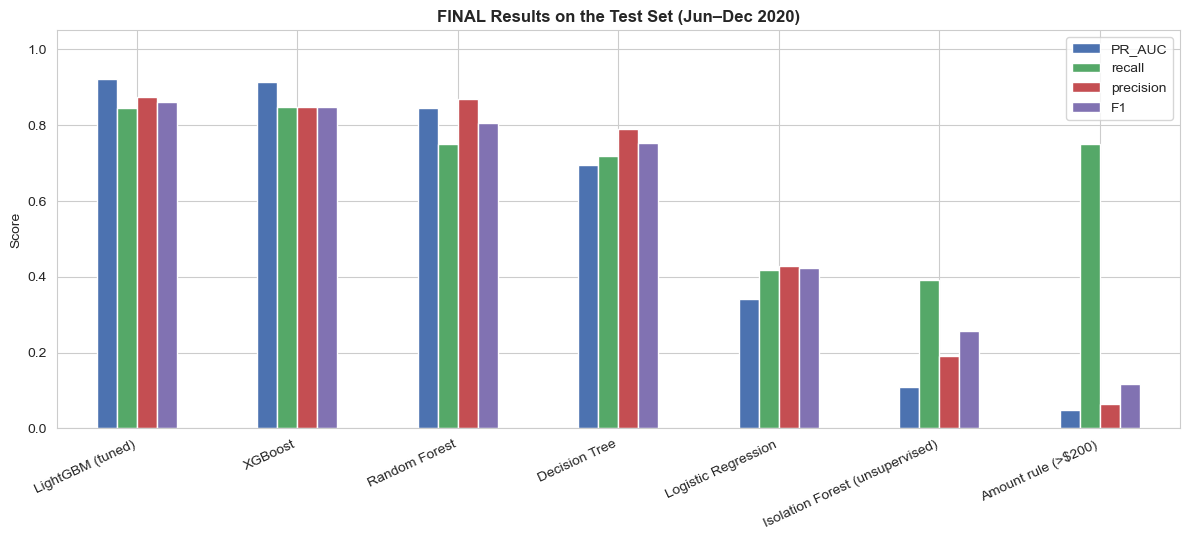

In [22]:
plot_df = test_results.set_index('model')[['PR_AUC', 'recall', 'precision', 'F1']]
fig, ax = plt.subplots(figsize=(12, 5.5))
plot_df.plot(kind='bar', ax=ax, color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'])
ax.set_title('FINAL Results on the Test Set (Jun–Dec 2020)', fontweight='bold')
ax.set_ylabel('Score')
ax.set_xlabel('')
ax.set_ylim(0, 1.05)
plt.xticks(rotation=25, ha='right')
save_fig('04_04_final_test_results.png')

In [23]:
# Save everything Notebook 5 needs (curves, confusion matrices, threshold analysis, SHAP)
pd.DataFrame({'trans_num': test_df['trans_num'].to_numpy(), 'is_fraud': y_test,
              **{f'p_{k}': v for k, v in test_probs.items()}}).to_pickle(os.path.join(BASE, 'test_predictions.pkl'))
pd.DataFrame({'trans_num': val_df['trans_num'].to_numpy(), 'is_fraud': y_val,
              **{f'p_{k}': v for k, v in val_probs.items()}}).to_pickle(os.path.join(BASE, 'val_predictions.pkl'))

for label in ['Logistic Regression', 'Decision Tree', 'XGBoost', 'LightGBM (tuned)']:
    joblib.dump(final_models[label], os.path.join(MODEL_DIR, label.replace(' ', '_').replace('(', '').replace(')', '') + '.joblib'))

joblib.dump({'FEATURES': FEATURES, 'BEST_STRATEGY': BEST_STRATEGY, 'BEST_N': BEST_N,
             'BEST_LGB_PARAMS': BEST_LGB_PARAMS, 'BEST_LGB_TREES': BEST_LGB_TREES,
             'thresholds': thresholds}, os.path.join(MODEL_DIR, 'run_config.joblib'))
print('Saved predictions, models and settings to', BASE)

Saved predictions, models and settings to C:\Users\adith\fraud-outputs


## Summary — what to send / what goes in the report
1. **Data splits** table (section A)
2. **Sampling comparison** chart + best strategy (section B)
3. **Model comparison on validation** (section C)
4. **Iteration curves** + key-points table (100/200/500/1000) (section D)
5. **Tuning** result: default vs tuned PR-AUC (section E)
6. **FINAL test results** table + chart (section F) — the headline numbers of the project

Notebook 5 will add confusion matrices, ROC/PR curves, threshold trade-offs and feature impact (SHAP).

In [1]:
import os, joblib, pandas as pd
BASE = os.path.join(os.path.expanduser('~'), 'fraud-outputs')
cfg = joblib.load(os.path.join(BASE, 'models', 'run_config.joblib'))
model = joblib.load(os.path.join(BASE, 'models', 'LightGBM_tuned.joblib'))

imp = pd.Series(model.booster_.feature_importance(importance_type='gain'), index=cfg['FEATURES'])
imp = (imp / imp.sum() * 100).sort_values(ascending=False).round(1)
imp.head(15)

log_amt                 61.1
is_night                 5.5
log_amt_vs_avg           4.8
cat_gas_transport        4.6
hour_cos                 2.8
log_hours_since_prev     2.4
age                      2.4
hour                     2.0
cat_grocery_pos          1.7
cat_home                 1.2
cat_food_dining          1.1
txn_count_24h            1.1
log_city_pop             1.1
cat_misc_pos             1.0
cat_grocery_net          1.0
dtype: float64